In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.visualization import plot_histogram

In [2]:
from qgan_lamarr import QGAN, SingleGaussian, RangeBinning

2026-05-08 09:27:04.414952: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-08 09:27:04.433308: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778225224.452091   18504 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778225224.457373   18504 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778225224.470557   18504 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

# Distribution embedding

{'000': 26, '001': 84, '010': 174, '011': 256, '100': 229, '101': 149, '110': 79, '111': 16}


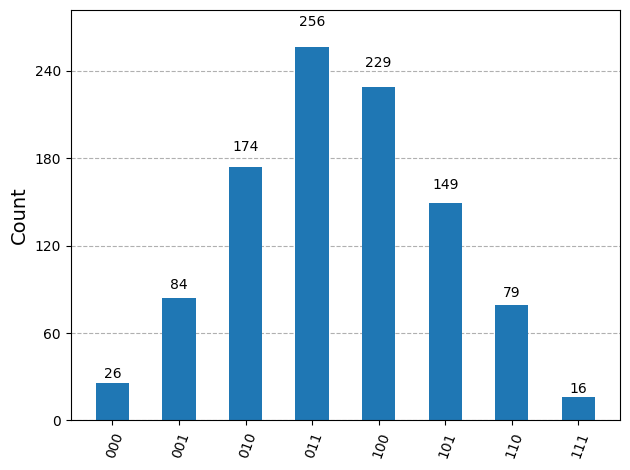

In [8]:
num_qubits = 3
nbins = 2**num_qubits

def sample_dist(_size, _nbins):
    _range = 0.25
    _sample = SingleGaussian(mean = 0.0, sd = 0.1,shots = _size)
    return RangeBinning(_sample, _nbins = _nbins, _range = (-_range, _range))

sample = sample_dist(2**10, nbins)
print(sample)
plot_histogram(sample)

# QGAN evaluation

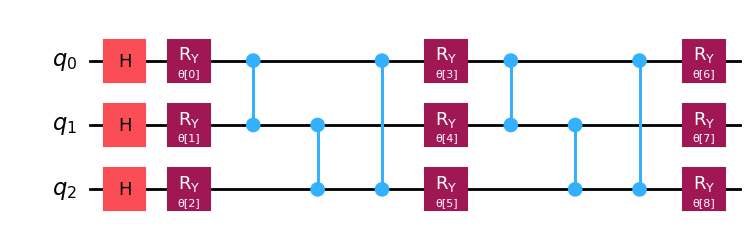

In [4]:
from qiskit.circuit import ParameterVector

reps = 2
qc = QuantumCircuit(num_qubits)
qc.h(range(num_qubits))
theta = ParameterVector("θ", length = (reps + 1) * num_qubits * 2)

p = 0

for q in range(num_qubits):
        qc.ry(theta[q], q)
        p += 1
for r in range(reps):

    for q in range(num_qubits):
        qc.cz(q%num_qubits, (q + 1)%num_qubits)
    for q in range(num_qubits):
        qc.ry(theta[p], q)
        p += 1
        
    

qc.draw("mpl")

In [5]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, InputLayer, LeakyReLU

discriminator = Sequential([
    InputLayer(shape=(nbins,)),
    Dense(50),
    LeakyReLU(),
    Dense(1, activation='linear') 
])

discriminator.summary()

2026-05-06 10:29:54.423655: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 50)             │           450 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 501 (1.96 KB)

 Trainable params: 501 (1.96 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
model = QGAN(num_qubits =int(np.log2(nbins)),
             generator = qc,
             discriminator = discriminator,
             real_dist = sample_dist,
             wass = True)

In [7]:
    epochs = 2000
    model.discriminator_lr = 1e-4
    model.fit(epochs = epochs, shots = 2**10, step_balance = 5.0, manager = True, opt = 'ADAM_PSR', lr = 1e-3)

Monitoring run: run_20260506_102954
Training started


  1%|          | 16/2000 [00:08<17:14,  1.92it/s]


KeyboardInterrupt: 

In [ ]:
baseline_js, baseline_js_std = model.compute_baseline_js(n_samples = 100)
print(f"Sampling Noise Floor (JS Baseline): {baseline_js:.4f}({baseline_js_std:.4f})")

In [ ]:
plt.plot(model.generator_losses, label = 'generator')
plt.plot(model.discriminator_losses, label = 'discriminator')
plt.legend()
plt.ylabel('loss')
plt.xlabel('epoch')
plt.show()

In [ ]:
plt.plot(model.metrics['jensen_shannon'], label = 'jensen_shannon')
plt.plot([0,epochs-1],[baseline_js,baseline_js])
plt.legend()
plt.xlabel('epoch')
plt.show()

In [ ]:
nsamples = 2**10
gen_res = model.get_sample(nsamples)
real_res = sample_dist(nsamples, nbins)
plot_histogram([gen_res, real_res], legend = ["generated","real sample"])